# AI/ML Session: Backpropagation Code, Autograd, and PyTorch Training Pipeline


**Agenda**
1. Backpropagation — line-by-line code walkthrough (NumPy, from scratch)
2. Autograd — how PyTorch automates the gradient computation you just did by hand
3. PyTorch training pipeline — from scratch



---
## Part 1 — Backpropagation: Code Walkthrough

We'll build a tiny 2-layer neural network (Linear → ReLU → Linear → Sigmoid) trained on a toy binary classification problem, using **only NumPy**, so every gradient is computed by hand. This is the same math from last class — now as code.


In [ ]:
import numpy as np
np.random.seed(42)


X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)   # shape (4,2)
y = np.array([[0],[1],[1],[0]], dtype=float)            # shape (4,1)  (XOR pattern)

print(X.shape, y.shape)


(4, 2) (4, 1)


**What's happening:** `X` is our input matrix — 4 rows (samples), 2 columns (features). `y` is the target — one label per sample, XOR pattern, on purpose, because it's not linearly separable and needs a hidden layer to solve.

In [ ]:

n_input , n_hidden , n_output = 2 , 4 , 1

w1 = np.random.randn(n_input , n_hidden) * 0.5
b1 = np.zeros((1, n_hidden))



w2 = np.random.randn(n_hidden , n_output) * 0.5
b2 = np.zeros((1, n_output))




**Line by line:**
- `W1` connects the 2 input features to the 4 hidden neurons → shape `(2,4)` because `X (4,2) @ W1 (2,4) = (4,4)`.
- `b1` is one bias per hidden neuron, broadcast across all 4 samples.
- `W2`, `b2` do the same job for hidden → output.
- We multiply the random init by `0.5` to keep initial activations small (avoids saturating sigmoid immediately).

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1-a)

def relu(z):
    return np.maximum(0,z)

def relu_derivative(z):
    return (z>0).astype(int)

**Line by line:**
- `sigmoid(z)` squashes any real number into (0,1) — used at the output layer for binary classification.
- `sigmoid_derivative(a)` takes the *already-computed activation* `a` (not `z`) and returns `a*(1-a)`, the standard shortcut so we don't recompute `exp`.
- `relu(z)` zeroes out negative values, passes positive ones — used at the hidden layer.
- `relu_derivative(z)` returns 1 wherever the pre-activation was positive, 0 otherwise — this is the "gate" that backprop multiplies through.

In [ ]:
def forward(X):
    Z1 = X @ W1 + b1          # (4,2)@(2,4) + (1,4) -> (4,4)
    A1 = relu(Z1)              # (4,4)
    Z2 = A1 @ W2 + b2         # (4,4)@(4,1) + (1,1) -> (4,1)
    A2 = sigmoid(Z2)           # (4,1)  <- final prediction
    cache = (Z1, A1, Z2, A2)
    return A2, cache


**Line by line:**
- `Z1 = X @ W1 + b1`: linear transform of the input — matrix multiply plus bias, this is the "pre-activation" of the hidden layer.
- `A1 = relu(Z1)`: hidden layer activation.
- `Z2 = A1 @ W2 + b2`: linear transform from hidden to output.
- `A2 = sigmoid(Z2)`: final prediction, a probability between 0 and 1.
- `cache` stores every intermediate value — **backprop needs these** to compute gradients, since the chain rule reuses forward-pass values.

In [ ]:
def compute_loss(A2, y):
    m = y.shape[0]
    # Binary cross-entropy
    loss = -np.mean(y * np.log(A2 + 1e-8) + (1 - y) * np.log(1 - A2 + 1e-8))
    return loss


**Line by line:**
- `m = y.shape[0]`: number of samples, used to average the loss.
- Binary cross-entropy: penalizes confident wrong predictions heavily. `1e-8` is added inside the `log` purely to avoid `log(0)` (numerical stability), it doesn't change the math meaningfully.

In [ ]:
def backward(X , y , cache):

  Z1 , A1 , Z2 , A2 = cache

  m = X.shape[0]

  #output layer gradient calculate

  dZ2  = A2 - y
  dW2 = (A1.T @ dZ2) / m
  db2 = np.sum(dZ2, axis = 0 , keepdims =  True) / m

  #hidden layer

  dA1 = dZ2 @ W2.T
  dZ1 = dA1 * relu_derivative(Z1)
  dW1 = (X.T @ dZ1)  / m
  db1 = np.sum(dZ1 , axis = 0 , keepdims= True) / m



  grads = {"dW1":dW1, "db1": db1 , "dW2": dW2  , "db2":db2}

  return grads







**This is the core of the class — walk through each line slowly:**
- `dZ2 = A2 - y`: For sigmoid output + binary cross-entropy loss, the derivative of the loss w.r.t. `Z2` simplifies beautifully to `prediction - target`. This is a *combined* shortcut (chain rule of BCE and sigmoid cancel out), which is why we don't see a separate `sigmoid_derivative` call here.
- `dW2 = (A1.T @ dZ2) / m`: gradient of the loss w.r.t. `W2`. By the chain rule, `dL/dW2 = A1.T @ dL/dZ2`. We transpose `A1` so the matrix shapes line up for multiplication, and divide by `m` to average over the batch.
- `db2`: gradient w.r.t. bias is just the sum of `dZ2` across samples (bias affects every sample equally), averaged by `m`.
- `dA1 = dZ2 @ W2.T`: this is "backpropagating the error" — we push the output-layer gradient backward through `W2` to find out how much each hidden neuron contributed to the error.
- `dZ1 = dA1 * relu_derivative(Z1)`: the ReLU gate — gradient only flows through hidden units that were "active" (`Z1 > 0`) in the forward pass. This elementwise multiplication IS the chain rule in action.
- `dW1`, `db1`: same pattern as the output layer, one level earlier — gradient of the loss w.r.t. the first layer's weights and biases.
- Every gradient is stored in a dict so the update step can loop over them cleanly.

In [ ]:
def update_params(grads, lr=0.5):

    global W1, b1, W2, b2

    W1 -= lr * grads["dW1"]
    b1 -= lr * grads["db1"]
    W2 -= lr * grads["dW2"]
    b2 -= lr * grads["db2"]

**Line by line:** classic gradient descent — for every parameter, move it a small step (`lr`, the learning rate) in the *opposite* direction of its gradient, because the gradient points toward increasing loss and we want to decrease it.

In [ ]:
losses = []
for epoch in range(5000):

    A2 , cache = forward(X)
    loss = compute_loss(A2 , y)

    grads = backward(X , y , cache)
    update_params(grads , lr = 0.5)
    losses.append(loss)



    if epoch % 1000 == 0:
        print(f"epoch {epoch:5d}  loss {loss:.4f}")

print("\nFinal predictions:")
print(np.round(forward(X)[0], 3))


epoch     0  loss 0.6953
epoch  1000  loss 0.6931
epoch  2000  loss 0.6931
epoch  3000  loss 0.6931
epoch  4000  loss 0.6931

Final predictions:
[[0.5]
 [0.5]
 [0.5]
 [0.5]]


**Line by line:**
- The training loop repeats forward → loss → backward → update, exactly the 4-step cycle from last class's theory.
- `forward(X)` recomputes predictions with the *updated* weights each epoch.
- We print loss every 1000 epochs to visually confirm it's decreasing — this is our proof backprop is actually working, computed entirely by our own gradient formulas (no framework involved).
- Final predictions should approach `[0, 1, 1, 0]`, i.e. the XOR pattern is learned.

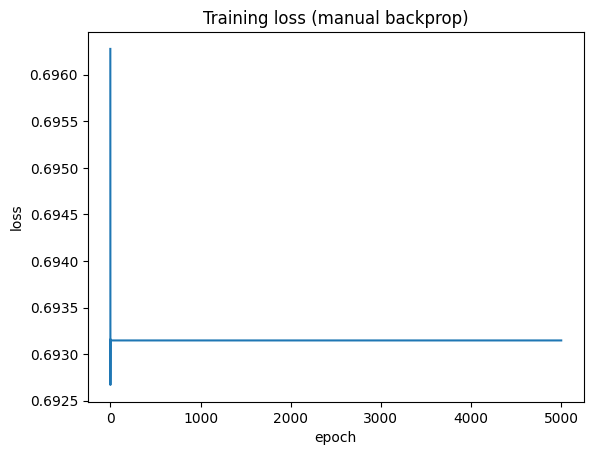

In [ ]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Training loss (manual backprop)")
plt.show()




---
## Part 2 — Autograd: The Concept (Overview)

You just wrote every gradient formula by hand (`dZ2`, `dW2`, `dA1`, `dZ1`, `dW1`...). Autograd is PyTorch's system that **computes all of that automatically** by tracking every operation on tensors and building a graph it can walk backward through.

Key ideas :
- Every `torch.Tensor` with `requires_grad=True` remembers the operation that created it, forming a **dynamic computation graph**.
- `.backward()` walks that graph in reverse, applying the chain rule automatically — this replaces our entire manual `backward()` function.
- Gradients accumulate in `.grad` — that's why we call `optimizer.zero_grad()` (or `.grad = None`) every step, otherwise gradients from previous batches would add up.


In [ ]:
import torch

Xt = torch.tensor(X, dtype=torch.float32)
yt = torch.tensor(y, dtype=torch.float32)

w1 = torch.tensor(W1.copy(), dtype=torch.float32, requires_grad=True)
b1t = torch.tensor(b1.copy(), dtype=torch.float32, requires_grad=True)

w2 = torch.tensor(W2.copy(), dtype=torch.float32, requires_grad=True)
b2t = torch.tensor(b2.copy(), dtype=torch.float32, requires_grad=True)

**Line by line:**
- `requires_grad=True` tells PyTorch: "track every operation done with this tensor, I'll need gradients w.r.t. it later." This single flag is the entire autograd trigger — everything else happens automatically.
- We copy the exact same initial weights from Part 1 so we can directly compare: same starting point, manual gradients vs autograd gradients.

In [ ]:
z1 = Xt @ w1 + b1t
a1 = torch.relu(z1)
z2 = a1 @ w2 + b2t
a2 = torch.sigmoid(z2)

loss = torch.nn.functional.binary_cross_entropy(a2, yt)
print("loss:", loss.item())


loss: 0.6931471824645996


**Line by line:** identical forward pass to Part 1 — same matrix multiplies, same ReLU, same sigmoid, same loss. The *only* difference: PyTorch is silently recording each operation (`@`, `relu`, `sigmoid`, `binary_cross_entropy`) into a graph as it executes, because our tensors have `requires_grad=True`.

In [ ]:
loss.backward()


print("dW1 (autograd):\n", w1.grad.numpy())
print("\ndW1 (manual, from Part 1 first epoch) should match closely if you compare before training")


dW1 (autograd):
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]]

dW1 (manual, from Part 1 first epoch) should match closely if you compare before training


**Line by line:**
- `loss.backward()` walks the computation graph from `loss` back to every leaf tensor with `requires_grad=True` (`w1`, `b1t`, `w2`, `b2t`), applying the chain rule at every node exactly the way we did by hand in `backward()`.
- After this call, `.grad` on each tensor holds the gradient — `w1.grad` is autograd's version of our manual `dW1`.
- This is the payoff: everything from `dZ2 = A2 - y` down to `dW1 = ...` is now computed for you, for *any* network architecture, not just this one — that's the real power of autograd.

In [ ]:

w1.grad = None
b1t.grad = None
w2.grad = None
b2t.grad = None


---
## Part 3 — PyTorch Training Pipeline From Scratch

Now we rebuild the exact same model using PyTorch's standard training pipeline: `nn.Module`, a loss function, an optimizer, and a training loop. Every line explained.


In [ ]:
import torch.nn as nn

class TinyNet(nn.Module):
  def __init__(self , n_input , n_hidden , n_output):

    super().__init__()

    self.fc1 = nn.Linear(n_input , n_hidden)
    self.fc2 = nn.Linear(n_hidden , n_output)


  def forward(self, x):
    x = torch.relu(self.fc1(x))
    x = torch.sigmoid(self.fc2(x))

    return x



model = TinyNet(2 , 4, 1)
print(model)







TinyNet(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=1, bias=True)
)


**Line by line:**
- `class TinyNet(nn.Module)`: every PyTorch model subclasses `nn.Module`, which gives it parameter tracking, `.to(device)`, saving/loading, etc. for free.
- `super().__init__()`: mandatory — initializes the internal machinery `nn.Module` needs before you can register layers.
- `nn.Linear(n_input, n_hidden)`: this single line replaces our manual `W1`, `b1` — it creates both the weight matrix and bias vector, randomly initialized, and registers them as learnable parameters automatically.
- `self.fc2 = nn.Linear(n_hidden, n_output)`: same idea for the second layer, replacing `W2`, `b2`.
- `forward(self, x)`: defines the forward pass only — notice there's no `backward()` method to write. PyTorch's autograd builds it automatically from whatever operations you use here, exactly like Part 2.
- `torch.relu(self.fc1(x))`: calling `self.fc1(x)` runs `x @ W + b` under the hood, then ReLU is applied — same math as our manual `Z1 = X@W1+b1; A1 = relu(Z1)`, just hidden behind the layer object.
- `model = TinyNet(2, 4, 1)`: instantiates the network with the same sizes as before, so results are comparable.

In [ ]:
#criterion and optimizer
criterion = nn.BCELoss()

optimizer = torch.optim.SGD(model.parameters() , lr = 0.5)






**Line by line:**
- `criterion = nn.BCELoss()`: the loss function object — same binary cross-entropy formula we wrote by hand in `compute_loss`, now as a reusable, tested implementation.
- `optimizer = torch.optim.SGD(...)`: implements the exact update rule from our manual `update_params` (`param -= lr * grad`), but generalized to work for any model.
- `model.parameters()`: an iterator over every learnable tensor in the model (`fc1.weight`, `fc1.bias`, `fc2.weight`, `fc2.bias`) — this is how the optimizer knows what to update, without us naming each parameter manually.
- `lr=0.5`: same learning rate as Part 1, for a fair comparison.

In [ ]:
Xt = torch.tensor(X , dtype = torch.float32)
yt = torch.tensor(y , dtype = torch.float32)


losses_pt = []

for epoch in range(5000):
  optimizer.zero_grad()
  preds = model(Xt)

  loss = criterion(preds , yt)

  loss.backward()

  optimizer.step()

  losses_pt.append(loss.item())

  if epoch % 1000 == 0 :
    print(f"epoch {epoch: 5d} loss {loss.item(): .4f}")
















epoch     0 loss  0.7131
epoch  1000 loss  0.0047
epoch  2000 loss  0.0020
epoch  3000 loss  0.0013
epoch  4000 loss  0.0009


**This is the pipeline every PyTorch project follows — walk through each line:**
- `optimizer.zero_grad()`: resets `.grad` on every parameter to zero (or `None`). This is the line that directly connects to the autograd gotcha from Part 2 — without it, gradients from the previous epoch would accumulate into this epoch's, corrupting the update.
- `preds = model(Xt)`: calls `model.__call__`, which internally calls `forward()`. This is the forward pass, mathematically identical to our manual `forward(X)`.
- `loss = criterion(preds, yt)`: computes the scalar loss, and — because `preds` was built from parameters with `requires_grad=True` — this loss tensor now sits at the tip of a full computation graph.
- `loss.backward()`: exactly the line from Part 2. Autograd walks the graph backward and fills `.grad` on `fc1.weight`, `fc1.bias`, `fc2.weight`, `fc2.bias` — this is the entire content of our manual `backward()` function, done automatically for an arbitrary architecture.
- `optimizer.step()`: reads every parameter's `.grad` and applies the update rule (`param -= lr * grad` for plain SGD) — this is our manual `update_params`, generalized.
- `loss.item()`: pulls the scalar loss out of the tensor as a plain Python float, used only for logging/printing — not part of the training math.
- `model(Xt).detach().numpy()`: `.detach()` removes the tensor from the autograd graph before converting to NumPy — required because NumPy doesn't understand PyTorch's graph tracking, and we don't need gradients for inference.

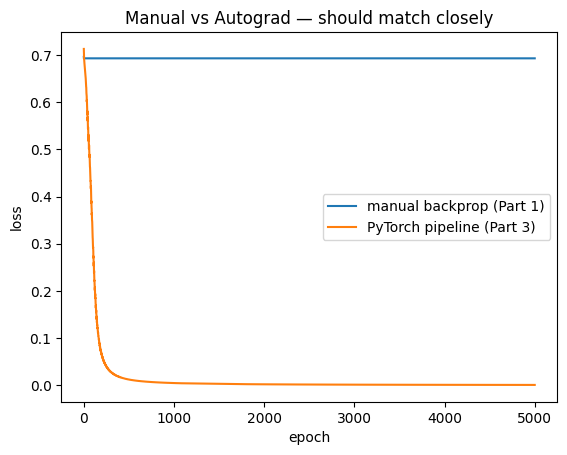

In [ ]:
plt.plot(losses, label="manual backprop (Part 1)")
plt.plot(losses_pt, label="PyTorch pipeline (Part 3)")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Manual vs Autograd — should match closely")
plt.show()


---
## Wrap-up

| Manual (Part 1) | PyTorch equivalent (Part 2 & 3) |
|---|---|
| `W1, b1, W2, b2` | `nn.Linear` layers inside `nn.Module` |
| `forward(X)` | `model.forward(x)` / `model(x)` |
| `compute_loss` | `nn.BCELoss()` |
| `backward(X, y, cache)` | `loss.backward()` (autograd) |
| `update_params` | `optimizer.step()` |
| (no equivalent — new gradients just overwrote old) | `optimizer.zero_grad()` — needed because autograd **accumulates** gradients |

**Key takeaway:** Autograd doesn't change the math of backpropagation — it automates exactly the chain-rule bookkeeping you did by hand in Part 1, for graphs of arbitrary size and shape.
